In [7]:
import pandas as pd

speeches_df = pd.read_csv('../data/clean/pm_speeches_en.csv', index_col="date", parse_dates=True)
speeches_df.tail()

,title,place,source,text
date,,,,
2026-01-26,Joint Op-Ed by Prime Minister Takaichi and Ita...,NaN,Prime Minister's Office of Japan,âJapan and Italy must help shape the future ...
2026-02-10,Message from the Prime Minister on the Occasio...,NaN,NaN,NaN
2026-02-16,Lunar New Year Message from Prime Minister TAK...,NaN,Prime Minister's Office of Japan,I send my heartfelt greetings to everyone cele...
2026-02-19,"AI Impact Summit, Video Message by Sanae Takai...",NaN,Ministry of Foreign Affairs of Japan,"1. Introduction\n\nI am Sanae Takaichi, Prime ..."
2026-02-19,Message from Prime Minister TAKAICHI Sanae On ...,NaN,Ministry of Foreign Affairs of Japan,I would like to extend my sincere congratulati...


In [9]:
import importlib
import keywords

importlib.reload(keywords)
from keywords import CATEGORY_KEYWORDS

print(CATEGORY_KEYWORDS)

{'defense': {'self-defense', 'threat', 'SDF', 'article 9', 'alliance', 'armed forces', 'self-defence', 'china', 'defense', 'military', 'deterrence', 'russia', 'military base', 'north korea', 'defence', 'navy', 'security council', 'missile', 'army', 'troops'}, 'economy': {'financial', 'financial contributions', 'business', 'wage', 'employment', 'growth', 'budget', 'stimulus', 'Bank of Japan', 'finance', 'trade', 'exchange rate', 'export', 'economic growth', 'gdp', 'economic', 'tax', 'market', 'economy', 'inflation', 'import', 'deficit', 'company', 'industry', 'interest rate', 'investment'}, 'nuclear': {'nuclear weapons', 'nuclear disarmament', 'atomic', 'fukushima', 'power plant', 'non-proliferation', 'atomic bomb survivors', 'world free of nuclear weapons', 'uranium', 'weapons', 'plutonium', 'radiation', 'nuclear', 'reactor'}, 'immigration': {'migrant', 'immigrant', 'visa', 'naturalization', 'border', 'migration', 'immigration', 'nationalisation', 'foreigner', 'nationalization', 'refug

In [13]:
import re
import matplotlib.pyplot as plt
import pandas as pd

from keywords import CATEGORY_KEYWORDS 

YEAR_START, YEAR_END = 2004, 2021
COLORS = ["blue", "red", "green", "orange"]

speeches_2004_2021 = speeches_df[
    (speeches_df.index.year >= YEAR_START) & (speeches_df.index.year <= YEAR_END)
]

category_patterns = {
    category: r"\b(" + "|".join(re.escape(kw) for kw in keywords) + r")\b"
    for category, keywords in CATEGORY_KEYWORDS.items()
}
total_per_year = speeches_2004_2021.resample("YE").size().reindex(
    pd.date_range(f"{YEAR_START}-01-01", f"{YEAR_END}-12-31", freq="YE"), fill_value=0
)

def category_speech_counts(pattern, df):
    matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
    counts = matches.resample("YE").size()
    return counts.reindex(
        pd.date_range(f"{YEAR_START}-01-01", f"{YEAR_END}-12-31", freq="YE"), fill_value=0
    )

category_year_counts = {
    category: category_speech_counts(pattern, speeches_2004_2021)
    for category, pattern in category_patterns.items()
}

category_year_normalised = {
    category: counts / total_per_year
    for category, counts in category_year_counts.items()
}

rows = []
for category, normalised in category_year_normalised.items():
    for date, value in normalised.items():
        rows.append({
            "category": category,
            "year": date.year,
            "keyword_speeches": category_year_counts[category][date],  # ← ADD
            "total_speeches": total_per_year[date],                    # ← ADD
            "normalised_share": value
        })

speeches_normalised = pd.DataFrame(rows).sort_values(["category", "year"])
speeches_normalised

/var/folders/jl/8r14gjwx1x91t9ywyhp6q75w0000gn/T/ipykernel_89799/3542734492.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
/var/folders/jl/8r14gjwx1x91t9ywyhp6q75w0000gn/T/ipykernel_89799/3542734492.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
/var/folders/jl/8r14gjwx1x91t9ywyhp6q75w0000gn/T/ipykernel_89799/3542734492.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
/var/folders/jl/8r14gjwx1x91t9ywyhp6q75w0000gn/T/ipykernel_89799/3542734492.py:23: UserWarning: This pa

,category,year,keyword_speeches,total_speeches,normalised_share
0,defense,2004,0,0,NaN
1,defense,2005,3,4,0.750000
2,defense,2006,1,3,0.333333
3,defense,2007,1,1,1.000000
4,defense,2008,5,5,1.000000
...,...,...,...,...,...
49,nuclear,2017,10,37,0.270270
50,nuclear,2018,6,20,0.300000
51,nuclear,2019,7,22,0.318182
52,nuclear,2020,5,15,0.333333


In [14]:
speeches_normalised.head(30)

,category,year,keyword_speeches,total_speeches,normalised_share
0,defense,2004,0,0,NaN
1,defense,2005,3,4,0.750000
2,defense,2006,1,3,0.333333
3,defense,2007,1,1,1.000000
4,defense,2008,5,5,1.000000
5,defense,2009,4,6,0.666667
6,defense,2010,6,10,0.600000
7,defense,2011,8,20,0.400000
8,defense,2012,7,19,0.368421
9,defense,2013,7,8,0.875000


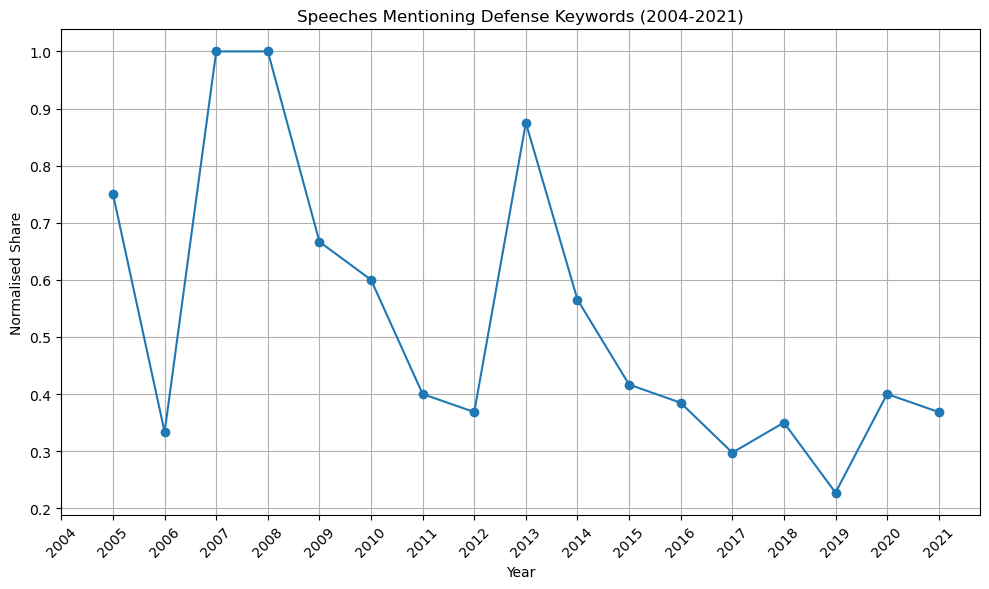

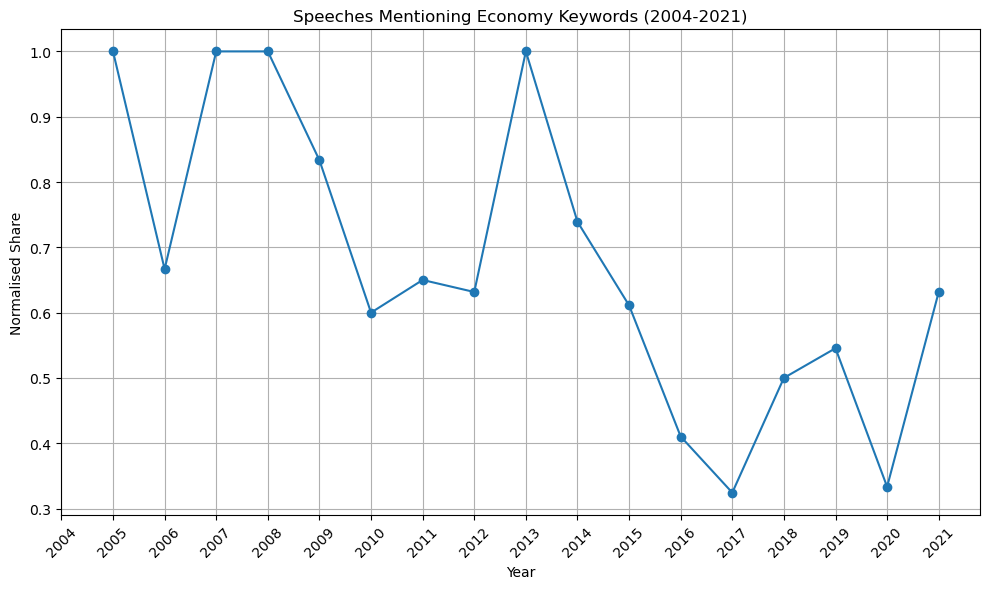

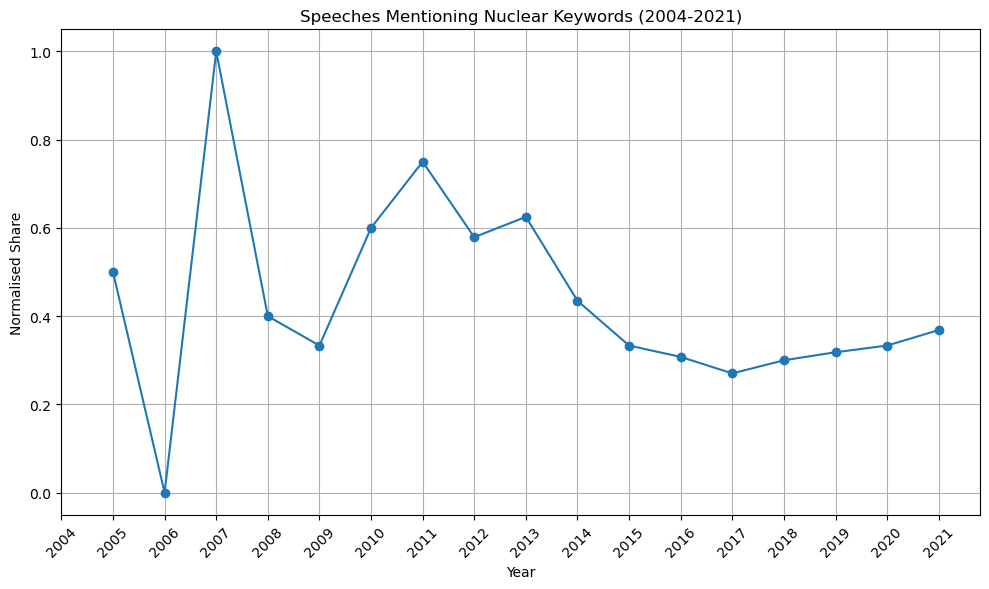

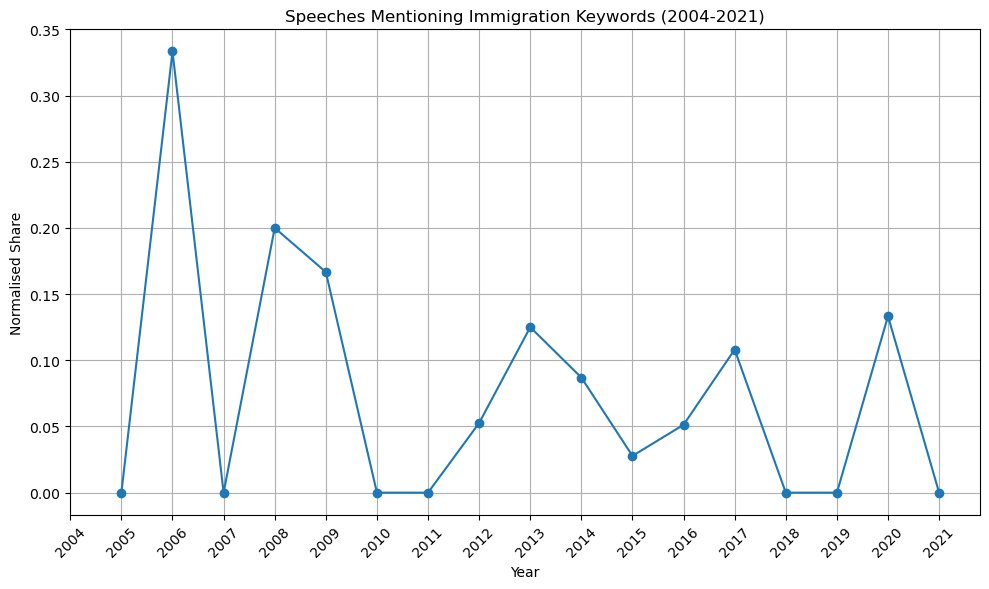

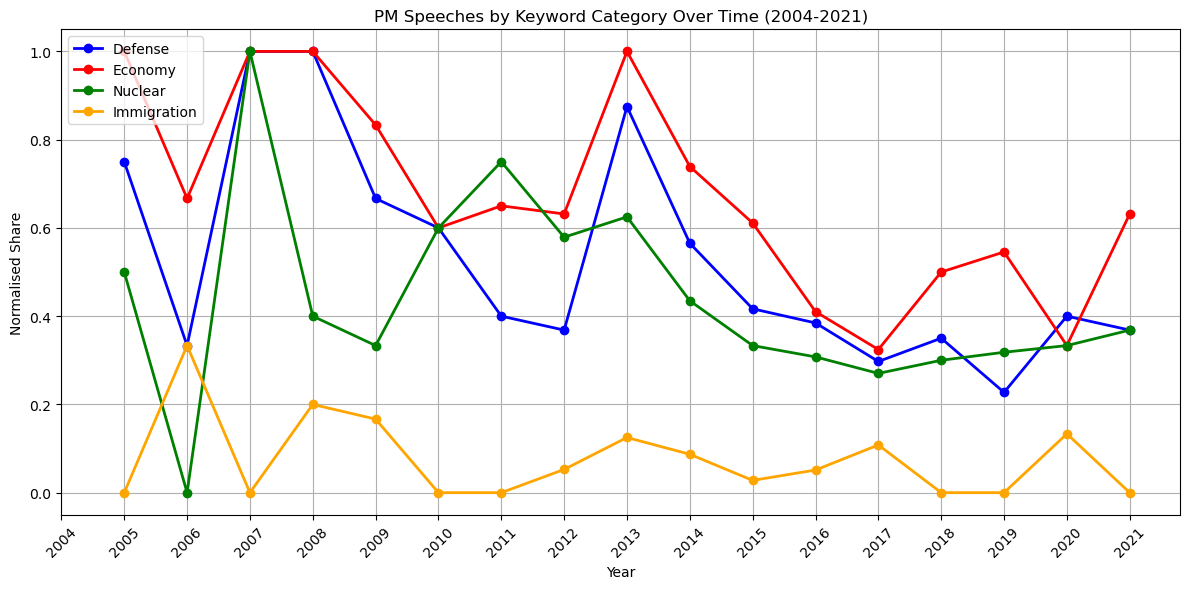

In [12]:
# Individual trend chart per category
for category, normalised in category_year_normalised.items():  # ← CHANGE: counts → normalised
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(normalised.index.year, normalised.values, marker="o")  # ← CHANGE: counts → normalised
    ax.set_xlabel("Year")
    ax.set_ylabel("Normalised Share")  # ← CHANGE: updated y-axis label
    ax.set_title(f"Speeches Mentioning {category.capitalize()} Keywords ({YEAR_START}-{YEAR_END})")
    ax.set_xticks(range(YEAR_START, YEAR_END + 1))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# Combined trend chart, all categories together
fig, ax = plt.subplots(figsize=(12, 6))
for (category, normalised), color in zip(category_year_normalised.items(), COLORS):  # ← CHANGE: counts → normalised
    ax.plot(normalised.index.year, normalised.values, label=category.capitalize(), color=color, marker="o", linewidth=2)  # ← CHANGE: counts → normalised

ax.set_xlabel("Year")
ax.set_ylabel("Normalised Share")  # ← CHANGE: updated y-axis label
ax.set_title(f"PM Speeches by Keyword Category Over Time ({YEAR_START}-{YEAR_END})")
ax.set_xticks(range(YEAR_START, YEAR_END + 1))
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left")
ax.grid(True)
plt.tight_layout()
plt.show()

In [16]:
speeches_normalised.to_csv('../data/clean/speeches_normalised.csv', index=False)